In [1]:
import folium

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from pathlib import Path
from glob import glob

In [2]:
mediciones_path = Path("../datos/mediciones/extraccion_20250807-184309.csv")
mediciones = pd.read_csv(
    mediciones_path,
    encoding='UTF-8',
    delimiter=';',
    low_memory=False
)

xlsx = glob("../datos/mediciones/Blanvira_Rincón del Bonete/*.xlsx")
# xlsx
df = pd.concat(pd.read_excel(excel_file) for excel_file in xlsx)
df["Fecha del dato"] = pd.to_datetime(df["Fecha del dato"])
# df.head()
daily_mean = df.groupby([df['Fecha del dato'].dt.date, df['Parametro']])['Valor'].mean().to_frame().reset_index()
# daily_mean.head()

In [3]:
print("Cantidad de días monitoreados", len(list(mediciones.fecha_muestra.unique())))
print("Cantidad de días monitoreados en Rincón de Bonete",
      len(
          list(
              mediciones[mediciones["id_estacion"] == 100642].fecha_muestra.unique()))
     ) 
mediciones[mediciones["id_estacion"] == 100642].groupby("param").fecha_muestra.count()

Cantidad de días monitoreados 6282
Cantidad de días monitoreados en Rincón de Bonete 40


param
Ace_Gra               1
Anatoxina            38
CloA_(in_situ_ug)    28
Clo_a                40
ColiTrm_MF            2
Cond                 39
Feo_a                40
Fico_(in_situ_ug)    28
Fico_(lab)           40
McyT                 40
NH4                   2
NO2-                 40
NO3                  40
NT                   40
NTK                  40
OD                   39
PO4                  40
PT                   40
Profundidad_Sitio    11
SDT                   1
SO4                   1
SST                  40
SatO                 39
Saxitoxina total     39
Tem                  39
Transp               13
Turb                 40
pH                   39
Name: fecha_muestra, dtype: int64

In [4]:
df.columns
print("Cantidad de días Boyas", len(list(df['Fecha del dato'].unique())))
print("Cantidad de días Boyas en Rincón de Bonete",
      len(
          list(
              df['Fecha del dato'].unique()))
     ) 
df.groupby("Parametro")['Fecha del dato'].count()

Cantidad de días Boyas 31751
Cantidad de días Boyas en Rincón de Bonete 31751


Parametro
Clorofila a                    30053
Conductividad                  30475
Ficocianina                    30624
Oxigeno disuelto               29678
Potencial de hidrogeno (pH)    26220
Saturación de oxígeno          29557
Temperatura                    28162
Turbidez                       29934
Name: Fecha del dato, dtype: int64

In [5]:
# filtrado por las estaciones de interés
print("Parámetros medidos por boya automatica: \n", df.Parametro.unique())
boya_chla = df[df['Parametro']=='Clorofila a'].copy()
print("Parámetros medidos por monitoreo: \n", mediciones.param.unique())
monintoreo_bonete = mediciones[mediciones["id_estacion"] == 100642]
monitoreo_chla = monintoreo_bonete[monintoreo_bonete["param"]=='Clo_a'].copy() # 'Clo_a' 'CloA_(in_situ_color)' 'CloA_(in_situ_ug)'
monitoreo_chla['valor_original'] = monitoreo_chla['valor_original'].replace('<LC', None)
monitoreo_chla['valor_original'] = pd.to_numeric(monitoreo_chla['valor_original'], errors='coerce')
# monitoreo_chla_a.head()

Parámetros medidos por boya automatica: 
 ['Turbidez' 'Temperatura' 'Oxigeno disuelto' 'Potencial de hidrogeno (pH)'
 'Saturación de oxígeno' 'Ficocianina' 'Clorofila a' 'Conductividad']
Parámetros medidos por monitoreo: 
 ['AlcT' 'Cond' 'pH' 'Tem' 'Turb' 'NH4' 'NO3' 'Clo_a'
 'Fico_(in_situ_color)' 'CloA_(in_situ_color)' 'std val a' 'std val b'
 'Sal' 'ColiTrm_MF' 'Floracionalgal' 'OD' 'Feo_a' 'SatO' 'SSF' 'SST' 'SSV'
 'Transp' 'AsT' 'CdT' 'CaT' 'CrT' 'FeT' 'MgT' 'HgT' 'NiT' 'PbT' 'KT' 'NaT'
 'ZnT' 'CNT' 'PO4' 'PT' 'NT' 'AOX' 'Glf' 'Ald' 'ppDDD' 'ppDDE' 'ppDDT'
 'Dld' 'Ends_a' 'Ends_b' 'Ends_SO4' 'HptCl' 'Lnd' 'MtCl' 'Atr' 'DBO5'
 'SstFnl' 'AMPA' 'NO2-' 'Color' 'DrzT' 'SDT' 'STT' 'STF' 'STV' 'Cl'
 'ColifTTM' 'Ecoli_SD' 'TOC' 'Fitoplancton_Total' 'Zooplancton_Total'
 'Picoplancton' 'Hifas.Esporas' 'Particulas.Inorg' 'Material.Part'
 'Esporas.Hongo' 'Espiculas.Espon' 'EndosulfanAlfaBeta'
 'Cianobacterias_Total' 'Oscillatoriales' 'Cianobacterias_Total (cel.eq)'
 'Oscillatoriales (cel.eq)'

## Localización de los puntos

In [6]:
# Coordenadas dos pontos com nomes
pontos = [
    {"coordenadas": (-32.828667, -56.418), "nombre": "Monitoreo N. 100642"},
    {"coordenadas": (-32.829722, -56.418889), "nombre": "Boya N. 649"}
]

# Criar o mapa centralizado no primeiro ponto
m = folium.Map(location=pontos[0]["coordenadas"], zoom_start=15)

# Adicionar os marcadores
for ponto in pontos:
    folium.Marker(location=ponto["coordenadas"], popup=ponto["nombre"]).add_to(m)

# Exibir o mapa
m

## Comparativos de valores de Chl_a

In [7]:
print("Valores boya")
boya_chla.groupby('Parametro').Valor.describe()

Valores boya


,count,mean,std,min,25%,50%,75%,max
Parametro,,,,,,,,
Clorofila a,30053.0,1.421113,1.68743,0.0,0.56,0.94,1.92,38.09


In [8]:
print("Valores monitoreo")
monitoreo_chla.groupby('parametro').valor_original.describe()

Valores monitoreo


,count,mean,std,min,25%,50%,75%,max
parametro,,,,,,,,
Clorofila_a_(lab),34.0,26.397059,48.97912,1.5,3.0,10.4,30.25,266.4


## ¿Cómo se distribuyen los valores de Chl_a a lo largo del tiempo?

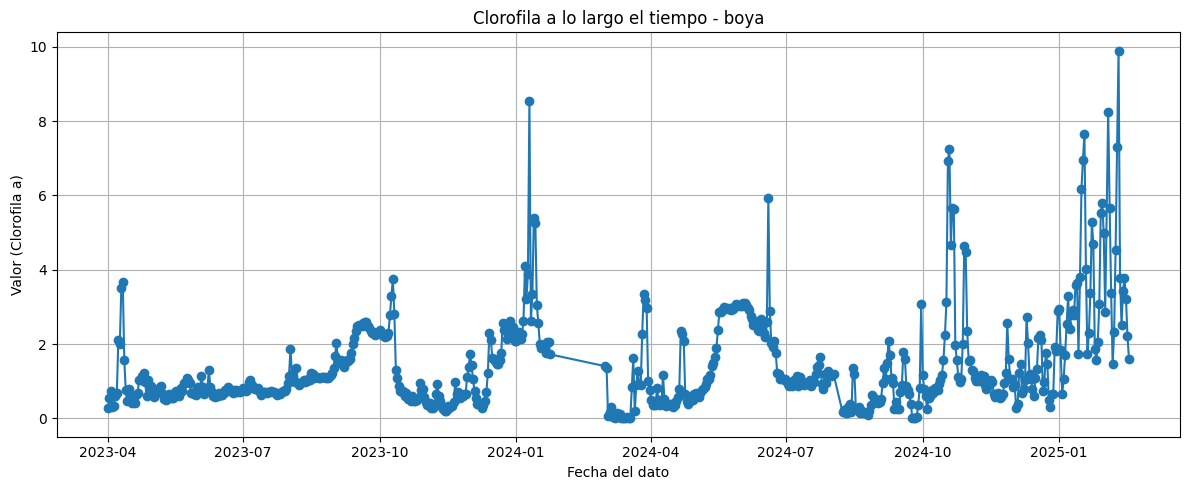

In [9]:
bya_chla_daily = daily_mean[daily_mean['Parametro']=='Clorofila a'].reset_index(drop=True)
plt.figure(figsize=(12, 5))
plt.plot(bya_chla_daily['Fecha del dato'], bya_chla_daily['Valor'], marker='o', linestyle='-')
plt.xlabel('Fecha del dato')
plt.ylabel('Valor (Clorofila a)')
plt.title('Clorofila a lo largo el tiempo - boya')
plt.grid(True)
plt.tight_layout()
plt.show()

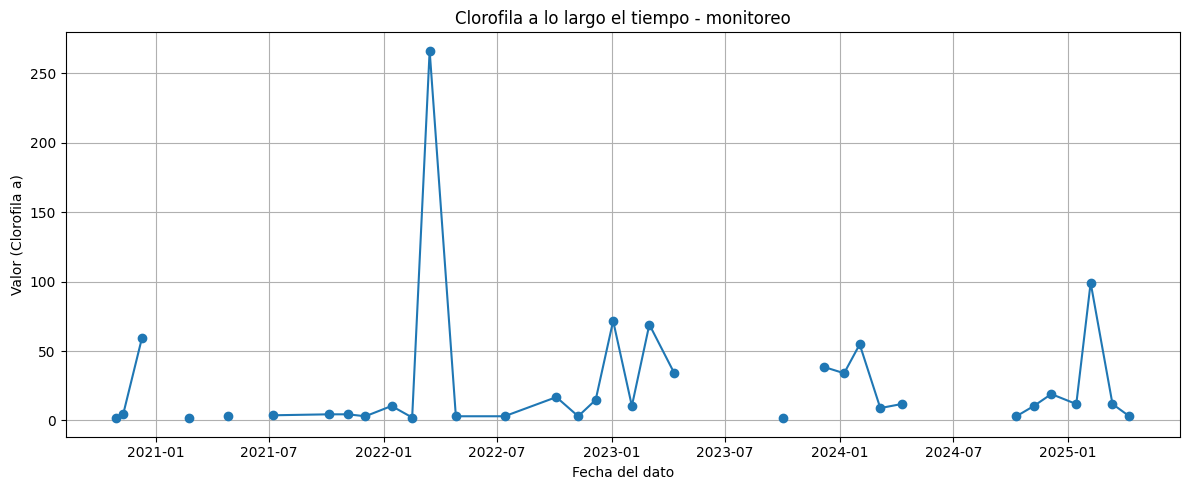

In [10]:
monitoreo_chla.fecha_muestra = pd.to_datetime(monitoreo_chla.fecha_muestra)
monitoreo_chla.sort_values('fecha_muestra', inplace=True)
# Plot
plt.figure(figsize=(12, 5))
plt.plot(monitoreo_chla.fecha_muestra, monitoreo_chla.valor_original, marker='o', linestyle='-')
plt.xlabel('Fecha del dato')
plt.ylabel('Valor (Clorofila a)')
plt.title('Clorofila a lo largo el tiempo - monitoreo')
plt.grid(True)
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ¿Cual es la diferencia en los valores de Chla_a medidos por la estación automatica (boya) y el monitoreo, en el Ricón del Bonete, Río Negro, para las mismas fechas?

In [11]:
bya_chla_daily['fecha'] = pd.to_datetime(bya_chla_daily['Fecha del dato']).dt.date
monitoreo_chla['fecha'] = pd.to_datetime(monitoreo_chla['fecha_muestra']).dt.date

bya_chla_daily.rename(columns={'Valor': 'valor_boya'}, inplace=True)
monitoreo_chla.rename(columns={'valor_original': 'valor_monitoreo'}, inplace=True)
comparacao = pd.merge(bya_chla_daily, monitoreo_chla, on='fecha', how='inner')

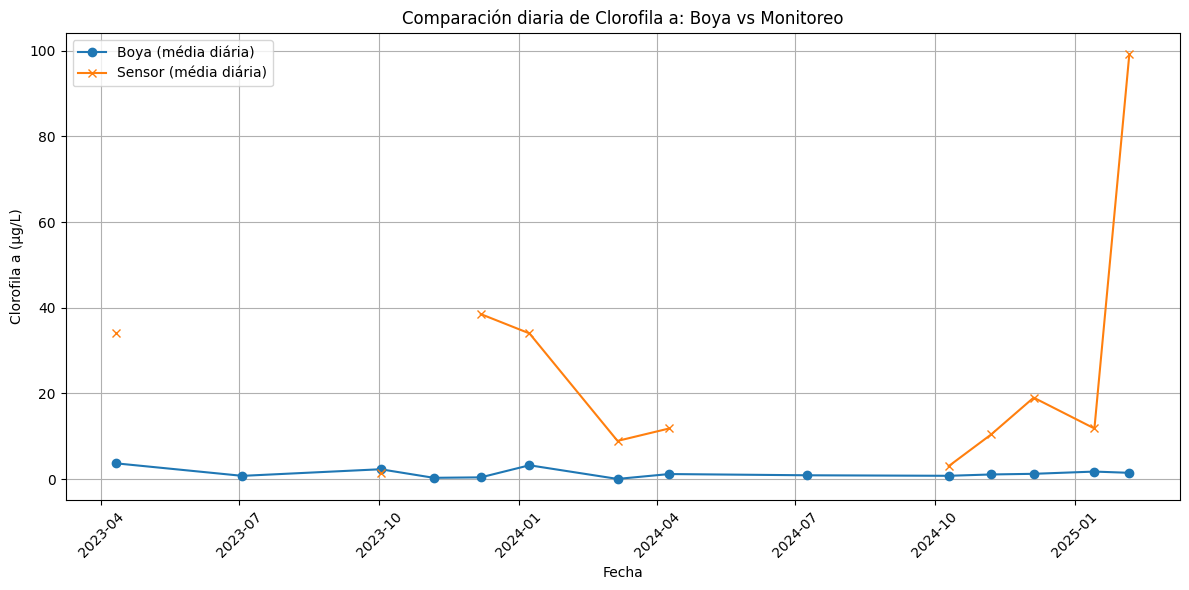

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(comparacao['fecha'], comparacao['valor_boya'], label='Boya (média diária)', marker='o')
plt.plot(comparacao['fecha'], comparacao['valor_monitoreo'], label='Sensor (média diária)', marker='x')
plt.xlabel('Fecha')
plt.ylabel('Clorofila a (μg/L)')
plt.title('Comparación diaria de Clorofila a: Boya vs Monitoreo')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()